01. DATA ACQUISITION & WEB SCRAPING


Scraping Property Listings from Zameen.com (Islamabad)

In [ ]:
import time
import re
import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import NoSuchElementException, TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup

def get_driver():
    options = Options()
    options.add_argument('--headless=new')
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')
    options.add_argument('--disable-gpu')
    options.add_argument('--window-size=1920,1080')
    options.add_argument(
        'user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/124.0.0.0 Safari/537.36'
    )
    options.add_argument('--disable-blink-features=AutomationControlled')
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option('useAutomationExtension', False)

    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=options)
    driver.execute_script("Object.defineProperty(navigator, 'webdriver', {get: () => undefined})")
    return driver

def safe_text(element):
    try:
        return element.text.strip()
    except:
        return ''

def safe_find(soup, selector):
    el = soup.select_one(selector)
    return el.get_text(strip=True) if el else ''


def get_listing_urls(driver, num_pages=20):
    all_urls = []
    base_url = "https://www.zameen.com/Houses_Property/Islamabad-3-{page}.html"

    for page in range(1, num_pages + 1):
        url = base_url.format(page=page)
        print(f"  Scanning page {page}/{num_pages}: {url}")
        try:
            driver.get(url)
            WebDriverWait(driver, 20).until(
                EC.presence_of_element_located((By.CSS_SELECTOR, 'li[aria-label="Listing"]'))
            )
            time.sleep(2)

            soup = BeautifulSoup(driver.page_source, 'html.parser')
            cards = soup.select('li[aria-label="Listing"]')
            page_urls = []
            for card in cards:
                a_tag = card.select_one('a[href*="/Property/"]')
                if a_tag and a_tag.get('href'):
                    href = a_tag['href']
                    if not href.startswith('http'):
                        href = 'https://www.zameen.com' + href
                    page_urls.append(href)

            new_urls = [u for u in page_urls if u not in all_urls]
            all_urls.extend(new_urls)
            print(f"    Found {len(new_urls)} new URLs. Total so far: {len(all_urls)}")

        except TimeoutException:
            print(f"    Timeout on page {page}, skipping.")
        except Exception as e:
            print(f"    Error on page {page}: {e}")

    all_urls = list(dict.fromkeys(all_urls))
    print(f"\nTotal unique listing URLs collected: {len(all_urls)}")
    return all_urls

def extract_property_details(driver, url):
    data = {
        'price':             '',
        'area':              '',
        'bedrooms':          '',
        'bathrooms':         '',
        'location':          '',
        'city':              'Islamabad',
        'property_type':     '',
        'built_year':        '',
        'parking_spaces':    '',
        'servant_quarters':  '',
        'store_rooms':       '',
        'kitchens':          '',
        'drawing_rooms':     '',
        'property_url':      url,
    }

    try:
        driver.get(url)
        WebDriverWait(driver, 20).until(
            EC.presence_of_element_located((By.CSS_SELECTOR, 'span[aria-label="Price"]'))
        )
        time.sleep(1.5)
        soup = BeautifulSoup(driver.page_source, 'html.parser')

        price_el = soup.select_one('span[aria-label="Price"]')
        if price_el:
            data['price'] = price_el.get_text(strip=True)

        area_el = soup.select_one('span[aria-label="Area"]')
        if area_el:
            data['area'] = area_el.get_text(strip=True)

        bed_el = soup.select_one('span[aria-label="Beds"]')
        if bed_el:
            data['bedrooms'] = bed_el.get_text(strip=True)

        bath_el = soup.select_one('span[aria-label="Baths"]')
        if bath_el:
            data['bathrooms'] = bath_el.get_text(strip=True)

        breadcrumbs = soup.select('nav[aria-label="breadcrumb"] a')
        if breadcrumbs and len(breadcrumbs) >= 3:
            data['location'] = ' > '.join(
                [b.get_text(strip=True) for b in breadcrumbs[1:]]
            )
        else:
            loc_el = soup.select_one('span[aria-label="Location"]')
            if loc_el:
                data['location'] = loc_el.get_text(strip=True)

        type_el = soup.select_one('span[aria-label="Type"]')
        if type_el:
            data['property_type'] = type_el.get_text(strip=True)

        detail_items = soup.select('ul._1l1fk98 li, ul[aria-label="Features"] li')
        for item in detail_items:
            spans = item.find_all('span')
            if len(spans) >= 2:
                label = spans[0].get_text(strip=True).lower()
                value = spans[1].get_text(strip=True)
                _parse_amenity(label, value, data)

        if not data['built_year']:
            all_li = soup.find_all('li')
            for li in all_li:
                text = li.get_text(separator=' ', strip=True).lower()
                spans = li.find_all('span')
                if len(spans) >= 2:
                    label = spans[0].get_text(strip=True).lower()
                    value = spans[-1].get_text(strip=True)
                    _parse_amenity(label, value, data)

        full_text = soup.get_text(separator='\n')
        lines = [l.strip() for l in full_text.split('\n') if l.strip()]

        for i, line in enumerate(lines):
            ll = line.lower()
            next_line = lines[i+1] if i+1 < len(lines) else ''

            if ll in ('bedrooms', 'beds') and not data['bedrooms']:
                nums = re.findall(r'\d+', next_line)
                if nums: data['bedrooms'] = nums[0]

            elif ll in ('bathrooms', 'baths') and not data['bathrooms']:
                nums = re.findall(r'\d+', next_line)
                if nums: data['bathrooms'] = nums[0]

            elif 'built in year' in ll and not data['built_year']:
                year = re.findall(r'\b(19|20)\d{2}\b', line + ' ' + next_line)
                if year: data['built_year'] = year[0]

            elif 'parking space' in ll and not data['parking_spaces']:
                nums = re.findall(r'\d+', next_line or line)
                if nums: data['parking_spaces'] = nums[0]

            elif 'servant quarter' in ll and not data['servant_quarters']:
                nums = re.findall(r'\d+', next_line or line)
                data['servant_quarters'] = nums[0] if nums else '1'

            elif 'store room' in ll and not data['store_rooms']:
                nums = re.findall(r'\d+', next_line or line)
                data['store_rooms'] = nums[0] if nums else '1'

            elif 'kitchen' in ll and 'kitchen' not in ll.replace('kitchen',''):
                if not data['kitchens']:
                    nums = re.findall(r'\d+', next_line or line)
                    data['kitchens'] = nums[0] if nums else '1'

            elif 'drawing room' in ll and not data['drawing_rooms']:
                nums = re.findall(r'\d+', next_line or line)
                data['drawing_rooms'] = nums[0] if nums else '1'

        return data

    except TimeoutException:
        print(f"    Timeout: {url}")
        return None
    except Exception as e:
        print(f"    Error scraping {url}: {e}")
        return None


def _parse_amenity(label, value, data):
    label = label.lower()
    if 'bedroom' in label or label == 'beds':
        if not data['bedrooms']:
            nums = re.findall(r'\d+', value)
            data['bedrooms'] = nums[0] if nums else value
    elif 'bathroom' in label or label == 'baths':
        if not data['bathrooms']:
            nums = re.findall(r'\d+', value)
            data['bathrooms'] = nums[0] if nums else value
    elif 'built in year' in label or 'built year' in label:
        if not data['built_year']:
            year = re.findall(r'\b(19|20)\d{2}\b', value)
            data['built_year'] = year[0] if year else value
    elif 'parking' in label:
        if not data['parking_spaces']:
            nums = re.findall(r'\d+', value)
            data['parking_spaces'] = nums[0] if nums else value
    elif 'servant' in label:
        if not data['servant_quarters']:
            nums = re.findall(r'\d+', value)
            data['servant_quarters'] = nums[0] if nums else '1'
    elif 'store room' in label:
        if not data['store_rooms']:
            nums = re.findall(r'\d+', value)
            data['store_rooms'] = nums[0] if nums else '1'
    elif 'kitchen' in label:
        if not data['kitchens']:
            nums = re.findall(r'\d+', value)
            data['kitchens'] = nums[0] if nums else '1'
    elif 'drawing' in label:
        if not data['drawing_rooms']:
            nums = re.findall(r'\d+', value)
            data['drawing_rooms'] = nums[0] if nums else '1'
    elif 'type' in label and 'property' in label:
        if not data['property_type']:
            data['property_type'] = value

if __name__ == '__main__':
    print("  ZAMEEN.COM SCRAPER — Islamabad Houses")
    driver = get_driver()
    print("\n[Phase 1] Collecting listing URLs...")
    urls = get_listing_urls(driver, num_pages=20)
    pd.Series(urls).to_csv('zameen_urls.csv', index=False, header=['url'])
    print(f"URLs saved to zameen_urls.csv")

    print(f"\n[Phase 2] Scraping details for up to {len(urls)} listings...")
    results = []
    target = min(len(urls), 325)

    for idx, url in enumerate(urls[:target]):
        print(f"  [{idx+1}/{target}] {url[:80]}...")
        details = extract_property_details(driver, url)
        if details:
            results.append(details)
        time.sleep(2.5)

        if (idx + 1) % 50 == 0:
            df_temp = pd.DataFrame(results)
            df_temp.to_csv('zameen_data_checkpoint.csv', index=False)
            print(f"Checkpoint saved: {len(results)} records so far")
    driver.quit()

    print("\n[Phase 3] Saving final dataset...")
    df = pd.DataFrame(results)
    cols = ['price', 'area', 'bedrooms', 'bathrooms', 'location', 'city',
            'property_type', 'built_year', 'parking_spaces',
            'servant_quarters', 'store_rooms', 'kitchens',
            'drawing_rooms', 'property_url']
    df = df[cols]

    df.to_csv('zameen_data.csv', index=False)
    print(f"\n✓ Done! {len(df)} records saved to zameen_data.csv")
    print("\nSample output:")
    print(df[['price','area','bedrooms','bathrooms','location','built_year']].head(10).to_string())

    print("\nColumn fill rates:")
    for col in cols[:-1]:
        filled = (df[col] != '').sum()
        print(f"  {col:20s}: {filled}/{len(df)} ({100*filled//max(len(df),1)}%)")

  ZAMEEN.COM SCRAPER — Islamabad Houses

[Phase 1] Collecting listing URLs...
  Scanning page 1/20: https://www.zameen.com/Houses_Property/Islamabad-3-1.html
    Found 25 new URLs. Total so far: 25
  Scanning page 2/20: https://www.zameen.com/Houses_Property/Islamabad-3-2.html
    Found 25 new URLs. Total so far: 50
  Scanning page 3/20: https://www.zameen.com/Houses_Property/Islamabad-3-3.html
    Found 25 new URLs. Total so far: 75
  Scanning page 4/20: https://www.zameen.com/Houses_Property/Islamabad-3-4.html
    Found 25 new URLs. Total so far: 100
  Scanning page 5/20: https://www.zameen.com/Houses_Property/Islamabad-3-5.html
    Found 25 new URLs. Total so far: 125
  Scanning page 6/20: https://www.zameen.com/Houses_Property/Islamabad-3-6.html
    Found 25 new URLs. Total so far: 150
  Scanning page 7/20: https://www.zameen.com/Houses_Property/Islamabad-3-7.html
    Found 25 new URLs. Total so far: 175
  Scanning page 8/20: https://www.zameen.com/Houses_Property/Islamabad-3-8.htm

2. DATA PREPROCESSING & FEATURE ENGINEERING

a. Handling the missing values

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('zameen_data.csv')
print(f"Original dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

print("\n1. HANDLING MISSING VALUES")
print(f"Missing values before preprocessing:\n{df.isnull().sum()}")
df = df.replace('', np.nan)
df = df.replace('-', np.nan)
df['parking_spaces'] = df['parking_spaces'].fillna(0)
df['servant_quarters'] = df['servant_quarters'].fillna(0)
df['store_rooms'] = df['store_rooms'].fillna(0)
df['built_year'] = df['built_year'].fillna(0)
df['property_type'] = df['property_type'].fillna(df['property_type'].mode()[0])

print(f"Missing values after preprocessing:\n{df.isnull().sum()}")

Original dataset shape: (325, 14)
Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'location', 'city', 'property_type', 'built_year', 'parking_spaces', 'servant_quarters', 'store_rooms', 'kitchens', 'drawing_rooms', 'property_url']

1. HANDLING MISSING VALUES
Missing values before preprocessing:
price                0
area                 0
bedrooms             0
bathrooms            0
location             0
city                 0
property_type        0
built_year          45
parking_spaces      83
servant_quarters    61
store_rooms         73
kitchens            18
drawing_rooms       28
property_url         0
dtype: int64
Missing values after preprocessing:
price                0
area                 0
bedrooms             4
bathrooms           11
location             0
city                 0
property_type        0
built_year           0
parking_spaces       0
servant_quarters     0
store_rooms          0
kitchens            18
drawing_rooms       28
property_url         0
dtype: 

b. Remove duplicate records

In [ ]:
print("2. REMOVING DUPLICATE RECORDS")
initial_count = len(df)
df = df.drop_duplicates(subset=['property_url'])
df = df.drop_duplicates()
print(f"Removed {initial_count - len(df)} duplicate records")
print(f"Dataset shape after removing duplicates: {df.shape}")

2. REMOVING DUPLICATE RECORDS
Removed 0 duplicate records
Dataset shape after removing duplicates: (325, 14)


c. Feature Engineering

In [ ]:
print("3. FEATURE ENGINEERING")

def convert_price_to_numeric(price_str):
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str).strip().lower()
    match = re.search(r'(\d+(?:\.\d+)?)', price_str)
    if not match:
        return np.nan

    value = float(match.group(1))

    if 'arab' in price_str:
        return value * 100
    elif 'crore' in price_str:
        return value
    elif 'lakh' in price_str:
        return value / 100
    else:
        return value

def convert_area_to_sq_yards(area_str):
    if pd.isna(area_str):
        return np.nan
    area_str = str(area_str).strip().lower()
    match = re.search(r'(\d+(?:\.\d+)?)', area_str)
    if not match:
        return np.nan
    value = float(match.group(1))

    if 'kanal' in area_str:
        return value * 500
    elif 'marla' in area_str:
        return value * 25
    else:
        return value

def extract_number(value_str):
    if pd.isna(value_str):
        return np.nan
    value_str = str(value_str).strip().lower()
    match = re.search(r'(\d+)', value_str)
    if match:
        return int(match.group(1))
    return np.nan

def extract_year(year_str):
    if pd.isna(year_str) or year_str == 0 or year_str == '0':
        return np.nan
    year_str = str(year_str)
    match = re.search(r'(19|20)\d{2}', year_str)
    if match:
        return int(match.group(0))
    return np.nan

print("Converting Price to Crores...")
df['price_crores'] = df['price'].apply(convert_price_to_numeric)

print("Converting Area to Square Yards...")
df['area_sq_yards'] = df['area'].apply(convert_area_to_sq_yards)

print("Extracting numeric bedrooms...")
df['bedrooms_num'] = df['bedrooms'].apply(extract_number)

print("Extracting numeric bathrooms...")
df['bathrooms_num'] = df['bathrooms'].apply(extract_number)

print("Extracting parking spaces...")
df['parking_num'] = df['parking_spaces'].apply(extract_number).fillna(0).astype(int)

print("Extracting servant quarters...")
df['servant_num'] = df['servant_quarters'].apply(extract_number).fillna(0).astype(int)

print("Extracting store rooms...")
df['store_rooms_num'] = df['store_rooms'].apply(extract_number).fillna(0).astype(int)

print("Extracting kitchens...")
df['kitchens_num'] = df['kitchens'].apply(extract_number).fillna(1).astype(int)

print("Extracting drawing rooms...")
df['drawing_rooms_num'] = df['drawing_rooms'].apply(extract_number).fillna(1).astype(int)

print("Extracting built year...")
df['built_year_num'] = df['built_year'].apply(extract_year)

3. FEATURE ENGINEERING
Converting Price to Crores...
Converting Area to Square Yards...
Extracting numeric bedrooms...
Extracting numeric bathrooms...
Extracting parking spaces...
Extracting servant quarters...
Extracting store rooms...
Extracting kitchens...
Extracting drawing rooms...
Extracting built year...


d. Data Cleaning & OUtlier Handling

In [ ]:
print("4. DATA CLEANING & OUTLIER HANDLING")

current_year = 2026
df['property_age'] = current_year - df['built_year_num']
df['property_age'] = df['property_age'].clip(0, 100)
df['property_age'] = df['property_age'].fillna(df['property_age'].median())

df['price_crores'] = df['price_crores'].fillna(df['price_crores'].median())
df['area_sq_yards'] = df['area_sq_yards'].fillna(df['area_sq_yards'].median())
df['bedrooms_num'] = df['bedrooms_num'].fillna(df['bedrooms_num'].median())
df['bathrooms_num'] = df['bathrooms_num'].fillna(df['bathrooms_num'].median())

mean_price = df['price_crores'].mean()
std_price = df['price_crores'].std()
price_upper_limit = mean_price + 3 * std_price
price_lower_limit = max(0, mean_price - 3 * std_price)

before_outlier = len(df)
df = df[(df['price_crores'] >= price_lower_limit) & (df['price_crores'] <= price_upper_limit)]
print(f"Removed {before_outlier - len(df)} price outliers")

mean_area = df['area_sq_yards'].mean()
std_area = df['area_sq_yards'].std()
area_upper_limit = mean_area + 3 * std_area
df = df[df['area_sq_yards'] <= area_upper_limit]
print(f"Removed area outliers, remaining: {len(df)} records")

df = df[df['bedrooms_num'] <= 15]
df = df[df['bathrooms_num'] <= 15]
df = df[df['price_crores'] > 0]
df = df[df['area_sq_yards'] > 0]

4. DATA CLEANING & OUTLIER HANDLING
Removed 5 price outliers
Removed area outliers, remaining: 315 records


e. Location Feature Engineering

In [ ]:
print("5. LOCATION FEATURE ENGINEERING")

def extract_sector(location_str):
    if pd.isna(location_str):
        return 'Unknown'

    location_str = str(location_str)
    sector_patterns = [
        r'(DHA Defence|DHA|Bahria Town|Top City|Gulberg|FECHS|Bani Gala|Park View|River Garden)',
        r'([A-Z]-\d+)',
        r'(Soan Garden|Kashmir Highway|Kuri Road|Lehtrar Road)'
    ]

    for pattern in sector_patterns:
        match = re.search(pattern, location_str, re.IGNORECASE)
        if match:
            return match.group(1)
    return 'Other'

df['sector'] = df['location'].apply(extract_sector)
sector_price_map = df.groupby('sector')['price_crores'].median().to_dict()
df['location_premium'] = df['sector'].map(sector_price_map)
df['location_premium'] = df['location_premium'].fillna(df['price_crores'].median())


5. LOCATION FEATURE ENGINEERING


f. Converting Categorical Variables

In [ ]:
print("6. CONVERTING CATEGORICAL VARIABLES")

categorical_cols = ['property_type', 'sector', 'city']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

df = pd.get_dummies(df, columns=['property_type', 'sector'], prefix=['type', 'sector'])

print("CREATING ADDITIONAL FEATURES")

df['rooms_per_area'] = (df['bedrooms_num'] + df['bathrooms_num']) / df['area_sq_yards']

df['luxury_score'] = (
    df['servant_num'] +
    df['store_rooms_num'] +
    df['parking_num'] * 0.5 +
    (df['drawing_rooms_num'] > 1).astype(int)
)

df['price_per_sq_yard'] = df['price_crores'] * 10000000 / df['area_sq_yards']


6. CONVERTING CATEGORICAL VARIABLES
Encoded property_type: {'House': 0}
Encoded sector: {'B-17': 0, 'Bahria Town': 1, 'Bani Gala': 2, 'D-12': 3, 'D-17': 4, 'DHA Defence': 5, 'E-11': 6, 'E-17': 7, 'E-18': 8, 'E-7': 9, 'F-10': 10, 'F-11': 11, 'F-18': 12, 'F-6': 13, 'F-7': 14, 'F-8': 15, 'FECHS': 16, 'G-10': 17, 'G-11': 18, 'G-13': 19, 'G-14': 20, 'G-15': 21, 'G-16': 22, 'G-9': 23, 'Gulberg': 24, 'H-13': 25, 'I-10': 26, 'I-11': 27, 'I-14': 28, 'Kashmir Highway': 29, 'Kuri Road': 30, 'Lehtrar Road': 31, 'O-9': 32, 'Other': 33, 'Park View': 34, 'River Garden': 35, 'Soan Garden': 36, 'Top City': 37}
Encoded city: {'Islamabad': 0}
CREATING ADDITIONAL FEATURES


g. Selecting Features for Modelling

In [ ]:
print("\n7. SELECTING FINAL FEATURES")

feature_cols = [
    'area_sq_yards',
    'bedrooms_num',
    'bathrooms_num',
    'parking_num',
    'servant_num',
    'store_rooms_num',
    'kitchens_num',
    'drawing_rooms_num',
    'property_age',
    'location_premium',
    'rooms_per_area',
    'luxury_score',
]

encoded_cols = [col for col in df.columns if col.startswith(('type_', 'sector_'))]
feature_cols.extend(encoded_cols)
target_col = 'price_crores'

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"\nFeatures selected ({len(feature_cols)} features):")
for col in feature_cols:
    print(f"  - {col}")
print(f"\nTarget variable: {target_col}")



7. SELECTING FINAL FEATURES

Features selected (52 features):
  - area_sq_yards
  - bedrooms_num
  - bathrooms_num
  - parking_num
  - servant_num
  - store_rooms_num
  - kitchens_num
  - drawing_rooms_num
  - property_age
  - location_premium
  - rooms_per_area
  - luxury_score
  - sector_encoded
  - type_House
  - sector_B-17
  - sector_Bahria Town
  - sector_Bani Gala
  - sector_D-12
  - sector_D-17
  - sector_DHA Defence
  - sector_E-11
  - sector_E-17
  - sector_E-18
  - sector_E-7
  - sector_F-10
  - sector_F-11
  - sector_F-18
  - sector_F-6
  - sector_F-7
  - sector_F-8
  - sector_FECHS
  - sector_G-10
  - sector_G-11
  - sector_G-13
  - sector_G-14
  - sector_G-15
  - sector_G-16
  - sector_G-9
  - sector_Gulberg
  - sector_H-13
  - sector_I-10
  - sector_I-11
  - sector_I-14
  - sector_Kashmir Highway
  - sector_Kuri Road
  - sector_Lehtrar Road
  - sector_O-9
  - sector_Other
  - sector_Park View
  - sector_River Garden
  - sector_Soan Garden
  - sector_Top City

Target var

h. Feature Scaling & Train - Test Split

In [ ]:
print("8. TRAIN-TEST SPLIT & FEATURE SCALING")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
numerical_features = ['area_sq_yards', 'bedrooms_num', 'bathrooms_num', 'parking_num',
                      'servant_num', 'store_rooms_num', 'kitchens_num', 'drawing_rooms_num',
                      'property_age', 'location_premium', 'rooms_per_area', 'luxury_score']

scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])
print("Feature scaling completed using StandardScaler")

print("SAVING PREPROCESSED DATA")
df.to_csv('zameen_data_preprocessed.csv', index=False)
pd.DataFrame(X_train).to_csv('X_train.csv', index=False)
pd.DataFrame(X_test).to_csv('X_test.csv', index=False)
pd.DataFrame(y_train).to_csv('y_train.csv', index=False)
pd.DataFrame(y_test).to_csv('y_test.csv', index=False)

print("Preprocessed files saved:")
print("  - zameen_data_preprocessed.csv")
print("  - X_train.csv, X_test.csv, y_train.csv, y_test.csv")

print("\nFINAL SUMMARY")
print(f"Original records: {initial_count}")
print(f"Final records after preprocessing: {len(df)}")
print(f"Features created: {len(feature_cols)}")
print(f"\nTarget variable statistics (Price in Crores):")
print(f"  Mean: {y.mean():.2f} Crore")
print(f"  Median: {y.median():.2f} Crore")
print(f"  Min: {y.min():.2f} Crore")
print(f"  Max: {y.max():.2f} Crore")
print(f"  Std: {y.std():.2f} Crore")

print("\nData preprocessing completed successfully")

8. TRAIN-TEST SPLIT & FEATURE SCALING
Training set size: 252
Test set size: 63
Feature scaling completed using StandardScaler
SAVING PREPROCESSED DATA
Preprocessed files saved:
  - zameen_data_preprocessed.csv
  - X_train.csv, X_test.csv, y_train.csv, y_test.csv

FINAL SUMMARY
Original records: 325
Final records after preprocessing: 315
Features created: 52

Target variable statistics (Price in Crores):
  Mean: 11.54 Crore
  Median: 7.80 Crore
  Min: 0.75 Crore
  Max: 70.00 Crore
  Std: 12.18 Crore

Data preprocessing completed successfully


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


3. MACHINE LEARNING MODEL DEVELOPMENT

a. Linear Regression

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("LINEAR REGRESSION RESULTS")
print(f"MAE: {mae:.2f} Crore")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f} Crore")
print(f"R2 Score: {r2:.4f}")

LINEAR REGRESSION RESULTS
MAE: 2.62 Crore
MSE: 15.10
RMSE: 3.89 Crore
R2 Score: 0.7971


b. Decision Tree

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("DECISION TREE RESULTS")
print(f"MAE: {mae:.2f} Crore")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f} Crore")
print(f"R2 Score: {r2:.4f}")

DECISION TREE RESULTS
MAE: 1.62 Crore
MSE: 6.90
RMSE: 2.63 Crore
R2 Score: 0.9072


c. Random Forest

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RANDOM FOREST RESULTS")
print(f"MAE: {mae:.2f} Crore")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f} Crore")
print(f"R2 Score: {r2:.4f}")

RANDOM FOREST RESULTS
MAE: 1.99 Crore
MSE: 12.36
RMSE: 3.52 Crore
R2 Score: 0.8338


d. Gradient Boosting

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("GRADIENT BOOSTING RESULTS")
print(f"MAE: {mae:.2f} Crore")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f} Crore")
print(f"R2 Score: {r2:.4f}")

GRADIENT BOOSTING RESULTS
MAE: 2.04 Crore
MSE: 9.99
RMSE: 3.16 Crore
R2 Score: 0.8658


e.  XGBoost

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

xgb_model = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("XGBOOST RESULTS")
print(f"MAE: {mae:.2f} Crore")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f} Crore")
print(f"R2 Score: {r2:.4f}")

XGBOOST RESULTS
MAE: 2.33 Crore
MSE: 18.50
RMSE: 4.30 Crore
R2 Score: 0.7514


e. CatBoost

In [ ]:
import pandas as pd
import numpy as np
!pip install catboost
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

cb_model = CatBoostRegressor(n_estimators=100, random_seed=42, verbose=False)
cb_model.fit(X_train, y_train)
y_pred = cb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("CATBOOST RESULTS")
print(f"MAE: {mae:.2f} Crore")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f} Crore")
print(f"R2 Score: {r2:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00
CATBOOST RESULTS
MAE: 1.98 Crore
MSE: 9.26
RMSE: 3.04 Crore
R2 Score: 0.8756


4. MODEL EVALUATION

MODEL PERFORMANCE COMPARISON
            Model  MAE (Crore)   MSE  RMSE (Crore)  R2 Score  MAPE (%)
    Decision Tree         1.62  6.90          2.63    0.9072     17.22
         CatBoost         1.98  9.26          3.04    0.8756     20.24
Gradient Boosting         2.04  9.99          3.16    0.8658     22.50
    Random Forest         1.99 12.36          3.52    0.8338     19.48
Linear Regression         2.62 15.10          3.89    0.7971     35.47
          XGBoost         2.33 18.50          4.30    0.7514     20.58

BEST PERFORMING MODEL
Model: Decision Tree
R2 Score: 0.9072 (90.7% variance explained)
MAPE: 17.22% average error
RMSE: 2.63 Crore
MAE: 1.62 Crore


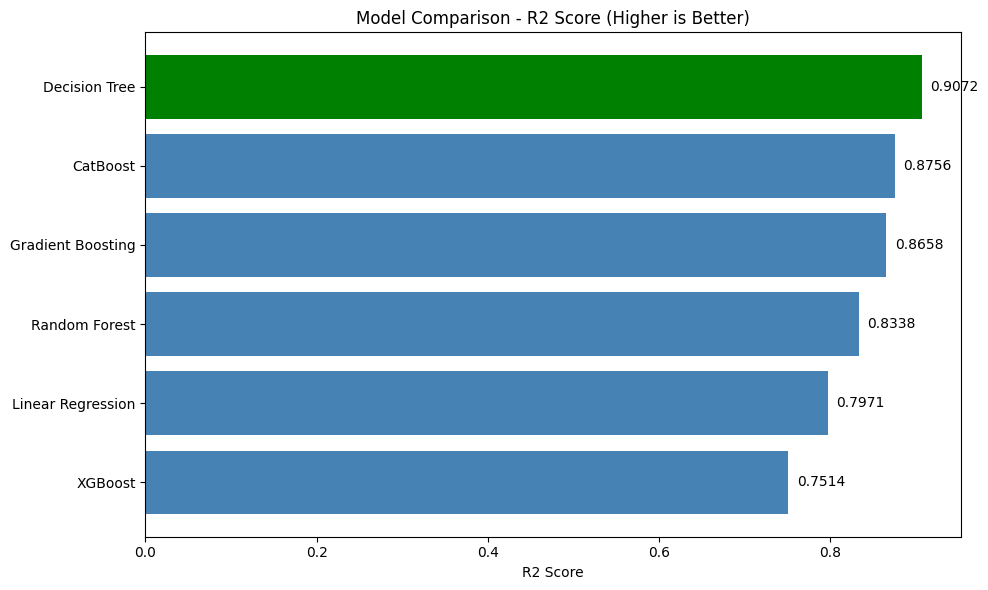

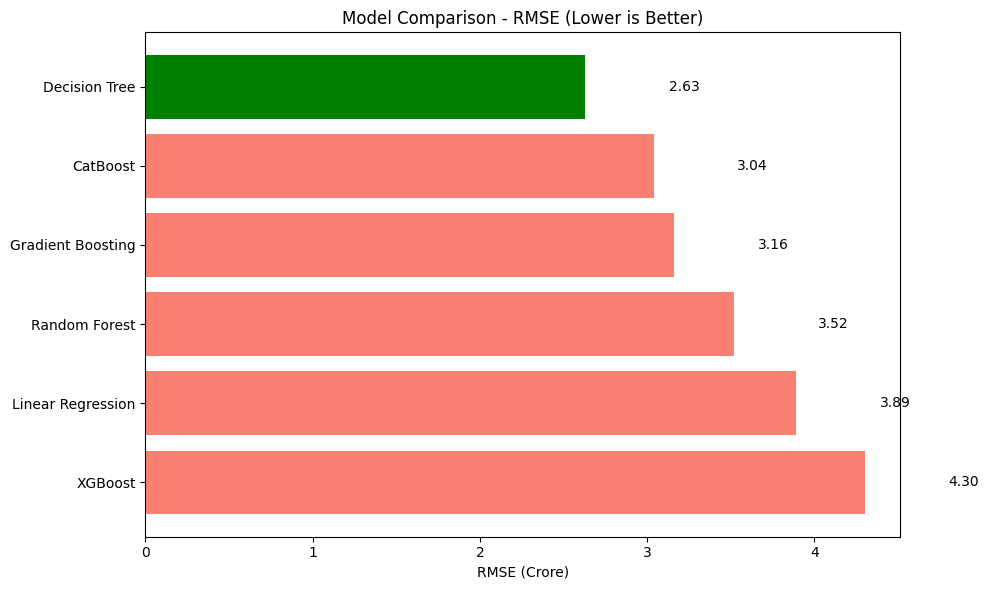

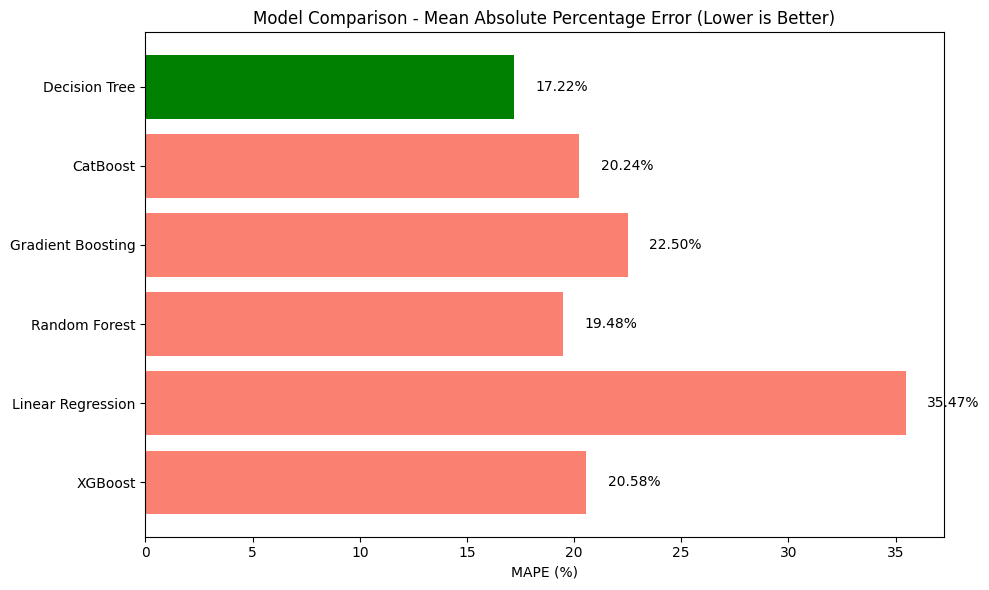

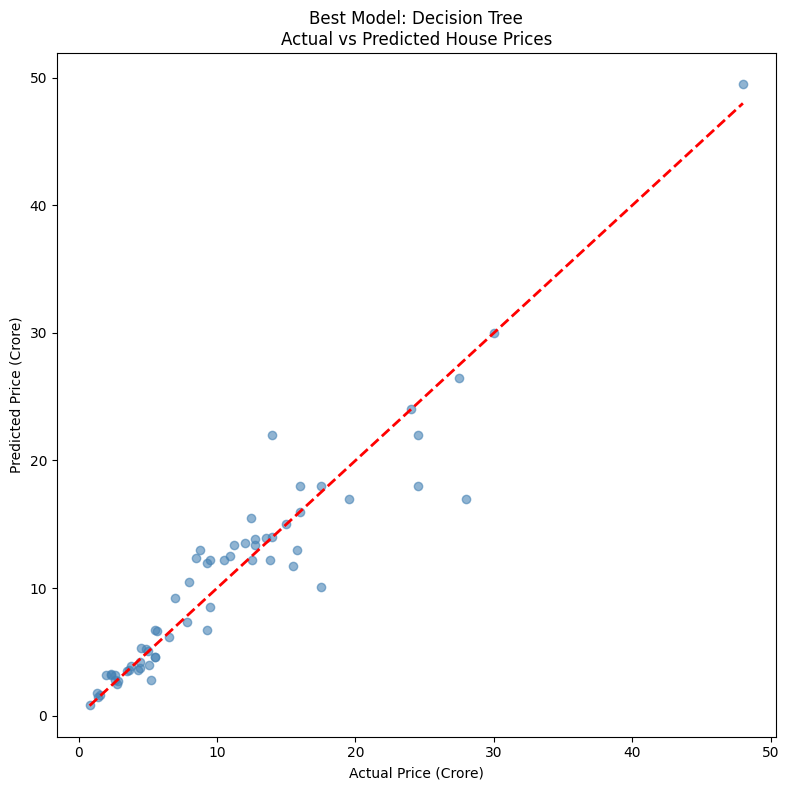

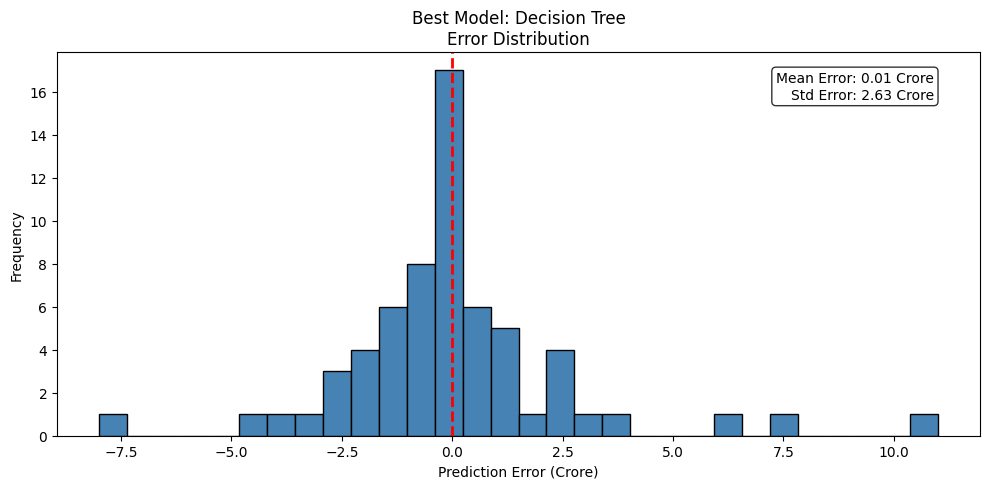


Results saved to model_comparison_results.csv


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'CatBoost': CatBoostRegressor(n_estimators=100, random_seed=42, verbose=False)
}

results = []
predictions_dict = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions_dict[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    results.append({
        'Model': name,
        'MAE (Crore)': round(mae, 2),
        'MSE': round(mse, 2),
        'RMSE (Crore)': round(rmse, 2),
        'R2 Score': round(r2, 4),
        'MAPE (%)': round(mape, 2)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2 Score', ascending=False)

print("MODEL PERFORMANCE COMPARISON")
print(results_df.to_string(index=False))

print("\nBEST PERFORMING MODEL")
best_model = results_df.iloc[0]
print(f"Model: {best_model['Model']}")
print(f"R2 Score: {best_model['R2 Score']} ({best_model['R2 Score']*100:.1f}% variance explained)")
print(f"MAPE: {best_model['MAPE (%)']}% average error")
print(f"RMSE: {best_model['RMSE (Crore)']} Crore")
print(f"MAE: {best_model['MAE (Crore)']} Crore")

plt.figure(figsize=(10, 6))
colors = ['green' if i == 0 else 'steelblue' for i in range(len(results_df))]
plt.barh(results_df['Model'], results_df['R2 Score'], color=colors)
plt.xlabel('R2 Score')
plt.title('Model Comparison - R2 Score (Higher is Better)')
plt.gca().invert_yaxis()
for i, v in enumerate(results_df['R2 Score']):
    plt.text(v + 0.01, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
colors = ['green' if i == 0 else 'salmon' for i in range(len(results_df))]
plt.barh(results_df['Model'], results_df['RMSE (Crore)'], color=colors)
plt.xlabel('RMSE (Crore)')
plt.title('Model Comparison - RMSE (Lower is Better)')
plt.gca().invert_yaxis()
for i, v in enumerate(results_df['RMSE (Crore)']):
    plt.text(v + 0.5, i, f'{v:.2f}', va='center')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
colors = ['green' if i == 0 else 'salmon' for i in range(len(results_df))]
plt.barh(results_df['Model'], results_df['MAPE (%)'], color=colors)
plt.xlabel('MAPE (%)')
plt.title('Model Comparison - Mean Absolute Percentage Error (Lower is Better)')
plt.gca().invert_yaxis()
for i, v in enumerate(results_df['MAPE (%)']):
    plt.text(v + 1, i, f'{v:.2f}%', va='center')
plt.tight_layout()
plt.show()

best_model_name = best_model['Model']
best_model_obj = models[best_model_name]
y_pred_best = predictions_dict[best_model_name]

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (Crore)')
plt.ylabel('Predicted Price (Crore)')
plt.title(f'Best Model: {best_model_name}\nActual vs Predicted House Prices')
plt.tight_layout()
plt.show()

errors = y_test - y_pred_best
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=30, edgecolor='black', color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Prediction Error (Crore)')
plt.ylabel('Frequency')
plt.title(f'Best Model: {best_model_name}\nError Distribution')
plt.text(0.95, 0.95, f'Mean Error: {errors.mean():.2f} Crore\nStd Error: {errors.std():.2f} Crore',
         transform=plt.gca().transAxes, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()

results_df.to_csv('model_comparison_results.csv', index=False)
print("\nResults saved to model_comparison_results.csv")

5. FINAL SYSTEM

In [38]:
import pandas as pd
import numpy as np
import re
from sklearn.tree import DecisionTreeRegressor

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

feature_names = X_train.columns.tolist()

df_original = pd.read_csv('zameen_data_preprocessed.csv')

location_columns = [col for col in feature_names if col.startswith('sector_')]
print("System Ready! Type 'exit' to quit.\n")

def convert_area_to_sq_yards(area_str):
    area_str = str(area_str).strip().lower()
    match = re.search(r'(\d+(?:\.\d+)?)', area_str)
    if not match:
        return None
    value = float(match.group(1))
    if 'kanal' in area_str:
        return value * 500
    elif 'marla' in area_str:
        return value * 25
    else:
        return value

def get_location_encoded(location_str, feature_names):
    location_str = str(location_str).strip().lower()
    location_encoded = {}
    for col in feature_names:
        if col.startswith('sector_'):
            location_encoded[col] = 0

    for col in feature_names:
        if col.startswith('sector_'):
            col_location = col.replace('sector_', '').replace('_', ' ').lower()
            if col_location == location_str:
                location_encoded[col] = 1
                break

    return location_encoded

def predict_price(area_sq_yards, bedrooms, bathrooms, location_str):
    input_data = {}

    for col in feature_names:
        if col == 'area_sq_yards':
            input_data[col] = area_sq_yards
        elif col == 'bedrooms_num':
            input_data[col] = bedrooms
        elif col == 'bathrooms_num':
            input_data[col] = bathrooms
        elif col.startswith('sector_'):
            input_data[col] = 0
        elif col.startswith('type_'):
            input_data[col] = 0
        else:
            input_data[col] = 0

    location_encoded = get_location_encoded(location_str, feature_names)
    for col, val in location_encoded.items():
        input_data[col] = val

    input_df = pd.DataFrame([input_data])
    prediction_crore = dt_model.predict(input_df)[0]

    return prediction_crore

def format_price(price_crore):
    if price_crore >= 1:
        return f"{price_crore:.2f} Crore"
    else:
        lakhs = price_crore * 100
        return f"{lakhs:.2f} Lakh"

while True:
    print("\nENTER PROPERTY DETAILS")

    area_input = input("Area (e.g., 10 Marla, 1 Kanal, 500 sq yards): ").strip()
    if area_input.lower() in ['exit', 'quit', '']:
        print("Thank you for using the House Price Prediction System!")
        break

    bedrooms_input = input("Number of Bedrooms (e.g., 5): ").strip()
    if bedrooms_input.lower() in ['exit', 'quit', '']:
        print("Thank you for using the House Price Prediction System!")
        break

    bathrooms_input = input("Number of Bathrooms (e.g., 6): ").strip()
    if bathrooms_input.lower() in ['exit', 'quit', '']:
        print("Thank you for using the House Price Prediction System!")
        break

    location_input = input("Location (e.g., DHA Defence, G-13, Bahria Town, F-11): ").strip()
    if location_input.lower() in ['exit', 'quit', '']:
        print("Thank you for using the House Price Prediction System!")
        break

    try:
        area_sq_yards = convert_area_to_sq_yards(area_input)
        if area_sq_yards is None:
            print("Error: Invalid area format. Please use format like '10 Marla' or '1 Kanal'")
            continue

        bedrooms = float(bedrooms_input)
        bathrooms = float(bathrooms_input)

        price_crore = predict_price(area_sq_yards, bedrooms, bathrooms, location_input)
        formatted_price = format_price(price_crore)

        print("\nPREDICTION RESULT")
        print(f"Area: {area_input} ({area_sq_yards:.0f} sq yards)")
        print(f"Bedrooms: {bedrooms}")
        print(f"Bathrooms: {bathrooms}")
        print(f"Location: {location_input}")
        print(f"Estimated Price: {formatted_price}")

    except ValueError:
        print("Error: Please enter valid numbers for bedrooms and bathrooms")
    except Exception as e:
        print(f"Error: {e}. Please check your inputs.")

System Ready! Type 'exit' to quit.


ENTER PROPERTY DETAILS
Area (e.g., 10 Marla, 1 Kanal, 500 sq yards): 12 MARLA
Number of Bedrooms (e.g., 5): 6
Number of Bathrooms (e.g., 6): 6
Location (e.g., DHA Defence, G-13, Bahria Town, F-11): g-13

PREDICTION RESULT
Area: 12 MARLA (300 sq yards)
Bedrooms: 6.0
Bathrooms: 6.0
Location: g-13
Estimated Price: 17.00 Crore

ENTER PROPERTY DETAILS
Area (e.g., 10 Marla, 1 Kanal, 500 sq yards): EXIT
Thank you for using the House Price Prediction System!
